<a href="https://colab.research.google.com/github/tejasabert/NHANES_FTI/blob/main/TejasAbert_NHANESFTI_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

How does BMI vary across the adult lifespan, and to what extent is the apparent BMI increase in older adults driven by age-related height loss rather than weight gain?


In [143]:
import pandas as pd
url = "https://raw.githubusercontent.com/frontiertechinstitute/datasets/refs/heads/main/Health%20and%20Nutrition%20(NHANES)/health_and_nutrition_combined_clean.csv"
df = pd.read_csv(url)
df.head(40)

,Unnamed: 0,SEQN,RIAGENDR,RIDRETH3,RIDAGEYR,BMXHT,BMXBMI,BMXWT,RIDEXPRG,WTMEC4YR
0,0,83732,1,3,62,1845.0,27.8,94.8,NaN,NaN
1,1,83733,1,3,53,1714.0,30.8,90.4,NaN,NaN
2,2,83734,1,3,78,1701.0,28.8,83.4,NaN,NaN
3,3,83741,1,4,22,1654.0,28.0,76.6,NaN,NaN
4,4,83744,1,4,56,1794.0,33.6,108.3,NaN,NaN
5,5,83747,1,3,46,1767.0,27.6,86.2,NaN,NaN
6,6,83750,1,7,45,1778.0,24.1,76.2,NaN,NaN
7,7,83755,1,4,67,1838.0,28.8,97.4,NaN,NaN
8,8,83769,1,6,49,1707.0,25.0,72.8,NaN,NaN
9,9,83777,1,6,56,1661.0,25.0,69.0,NaN,NaN


In [144]:
df = pd.read_csv(url)

# drop rows missing BMI height or weight
df = df.dropna(subset=['BMXBMI', 'BMXHT', 'BMXWT'])

# remove pregnant participants
df = df[df['RIDEXPRG'] != 1]

# convert height from mm to cm
df['BMXHT'] = df['BMXHT'] / 10

# rename the columns
df = df.rename(columns={
    'RIDAGEYR': 'Age',
    'RIAGENDR': 'Sex',
    'RIDRETH3': 'Race',
    'BMXHT': 'Height_cm',
    'BMXWT': 'Weight_kg',
    'BMXBMI': 'BMI'
})

# turn numbers into labels
df['Sex'] = df['Sex'].map({1: 'Male', 2: 'Female'})
df['Race'] = df['Race'].map({
    1: 'Mexican American',
    2: 'Other Hispanic',
    3: 'Non-Hispanic White',
    4: 'Non-Hispanic Black',
    6: 'Non-Hispanic Asian',
    7: 'Other/Multi'
})

#checking
print(f"Rows left: {len(df)}")
print(df.head())


Rows left: 10457
   Unnamed: 0   SEQN   Sex                Race  Age  Height_cm   BMI  \
0           0  83732  Male  Non-Hispanic White   62      184.5  27.8   
1           1  83733  Male  Non-Hispanic White   53      171.4  30.8   
2           2  83734  Male  Non-Hispanic White   78      170.1  28.8   
3           3  83741  Male  Non-Hispanic Black   22      165.4  28.0   
4           4  83744  Male  Non-Hispanic Black   56      179.4  33.6   

   Weight_kg  RIDEXPRG  WTMEC4YR  
0       94.8       NaN       NaN  
1       90.4       NaN       NaN  
2       83.4       NaN       NaN  
3       76.6       NaN       NaN  
4      108.3       NaN       NaN  


In [147]:
#remove unneeded colunmn
df = df.drop(columns=['Unnamed: 0'])

In [145]:
#drop this becuase its NaNs
df = df.drop(columns=['WTMEC4YR'])

In [146]:
print(len(df))

10457


In [148]:
# drop pregnant
df = df.drop(columns=['RIDEXPRG'])
#check for remaining NaNs
print(df.isna().sum())

SEQN         0
Sex          0
Race         0
Age          0
Height_cm    0
BMI          0
Weight_kg    0
dtype: int64


In [149]:
#cleaned version
df.to_csv("health_cleaned.csv", index=False)

In [150]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 10457 entries, 0 to 10613
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   SEQN       10457 non-null  int64  
 1   Sex        10457 non-null  object 
 2   Race       10457 non-null  object 
 3   Age        10457 non-null  int64  
 4   Height_cm  10457 non-null  float64
 5   BMI        10457 non-null  float64
 6   Weight_kg  10457 non-null  float64
dtypes: float64(3), int64(2), object(2)
memory usage: 653.6+ KB


In [154]:
df.groupby('Age')[['BMI','Weight_kg','Height_cm']].mean()

,BMI,Weight_kg,Height_cm
Age,,,
20,26.637931,76.080000,168.616552
21,28.782051,80.617949,167.183761
22,27.799429,79.321714,168.682286
23,26.955758,75.951515,167.909091
24,28.147500,78.966875,167.554375
...,...,...,...
76,29.362069,81.421839,166.595402
77,29.920690,81.482759,164.342529
78,29.005952,78.305952,163.972619


/tmp/ipykernel_684/887996093.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_bmi = df.groupby('AgeGroup')['BMI'].mean()
/tmp/ipykernel_684/887996093.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_weight = df.groupby('AgeGroup')['Weight_kg'].mean()
/tmp/ipykernel_684/887996093.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_height = df.groupby('AgeGroup')['Height_cm'].mean()


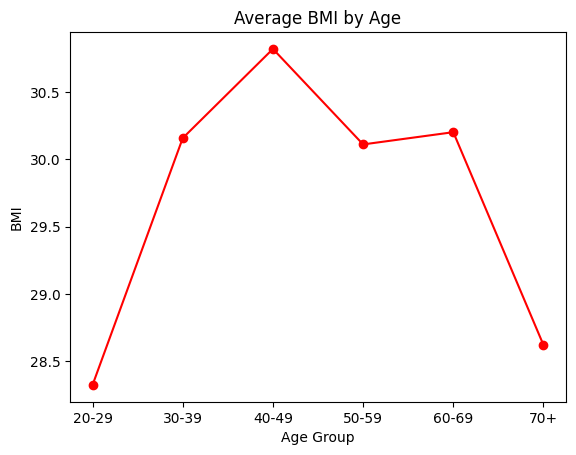

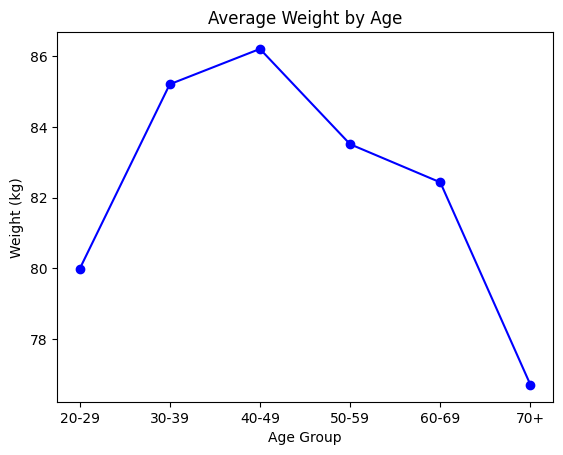

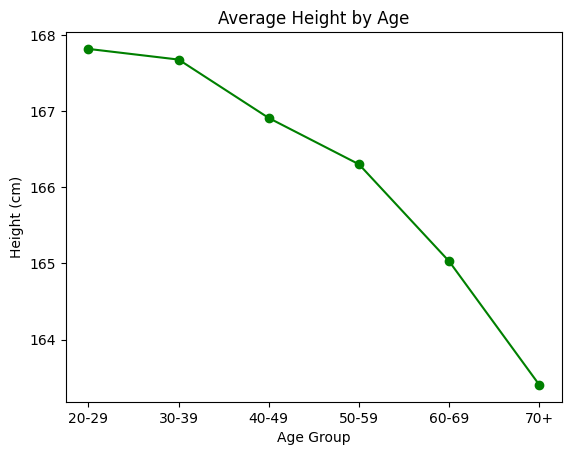

AgeGroup
20-29    28.322661
30-39    30.157844
40-49    30.820793
50-59    30.110774
60-69    30.201787
70+      28.619231
Name: BMI, dtype: float64
AgeGroup
20-29    79.979405
30-39    85.203832
40-49    86.202344
50-59    83.509150
60-69    82.431565
70+      76.706716
Name: Weight_kg, dtype: float64
AgeGroup
20-29    167.821446
30-39    167.681198
40-49    166.912800
50-59    166.304169
60-69    165.028154
70+      163.403419
Name: Height_cm, dtype: float64


In [139]:
import matplotlib.pyplot as plt

#age groups
df['AgeGroup'] = pd.cut(df['Age'], bins=[20,30,40,50,60,70,81],
                        labels=['20-29','30-39','40-49','50-59','60-69','70+'])
# averages
avg_bmi = df.groupby('AgeGroup')['BMI'].mean()
avg_weight = df.groupby('AgeGroup')['Weight_kg'].mean()
avg_height = df.groupby('AgeGroup')['Height_cm'].mean()

# chart 1 (BMI)
plt.plot(avg_bmi.index, avg_bmi.values, marker='o', color='red')
plt.title('Average BMI by Age')
plt.xlabel('Age Group')
plt.ylabel('BMI')
plt.show()

# chart 2 (Weight)
plt.plot(avg_weight.index, avg_weight.values, marker='o', color='blue')
plt.title('Average Weight by Age')
plt.xlabel('Age Group')
plt.ylabel('Weight (kg)')
plt.show()

# chart 3 (Height)
plt.plot(avg_height.index, avg_height.values, marker='o', color='green')
plt.title('Average Height by Age')
plt.xlabel('Age Group')
plt.ylabel('Height (cm)')
plt.show()

print(avg_bmi)
print(avg_weight)
print(avg_height)

In [138]:
max_bmi = df['BMI'].max()
print(f"The maximum BMI is: {max_bmi}")

The maximum BMI is: 86.2
